# Visualize CO2 Scenarios

## CO2 historical

MLO and SPO Averaged Products
yearly

https://scrippsco2.ucsd.edu/data/atmospheric_co2/averaged_products.html

Cite as: C. D. Keeling, S. C. Piper, R. B. Bacastow, M. Wahlen, T. P. Whorf, M. Heimann, and H. A. Meijer, Atmospheric CO2 and 13CO2 exchange with the terrestrial biosphere and oceans from 1978 to 2000: observations and carbon cycle implications, pages 83-113, in "A History of Atmospheric CO2 and its effects on Plants, Animals, and Ecosystems", editors, Ehleringer, J.R., T. E. Cerling, M. D. Dearing, Springer Verlag, New York, 2005.

Scripps CO2 program data and graphics on scrippsco2.ucsd.edu are licensed under a CC BY license, Creative Commons Attribution 4.0 International License (http://creativecommons.org/licenses/by/4.0/), which clarifies appropriate uses and requirements, including that credit be given to the Scripps Institution of Oceanography at UC San Diego.

In [1]:
import pandas as pd
import numpy as np

from aquacrop_slovenia import config

In [2]:
co2_historical = pd.read_csv(config.CO2_DIR / "mlo_spo_annual_mean.csv", skiprows=8, names=["year", "co2"])
co2_historical = co2_historical.astype(dtype={"year": np.int16, "co2": np.float32})
co2_historical

,year,co2
0,1957,NaN
1,1958,NaN
2,1959,315.809998
3,1960,316.679993
4,1961,317.380005
...,...,...
63,2020,412.019989
64,2021,414.100006
65,2022,416.309998
66,2023,418.660004


In [3]:
co2_historical.describe()

,year,co2
count,68.00000,65.000000
mean,1990.50000,357.922485
std,19.77372,30.739164
min,1957.00000,315.809998
25%,1973.75000,330.339996
50%,1990.50000,354.239990
75%,2007.25000,382.070007
max,2024.00000,418.660004


<Axes: xlabel='year'>

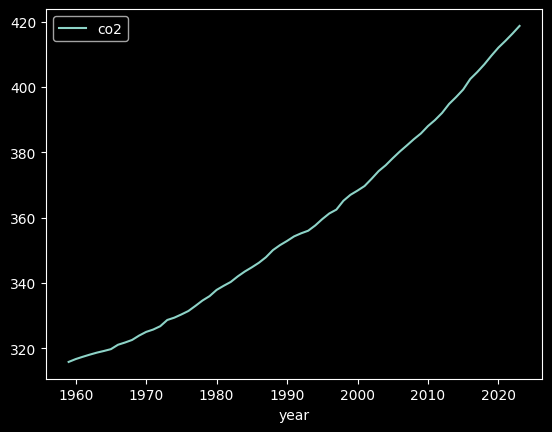

In [4]:
co2_historical.plot(x="year", y="co2")

## CO2 RCP scenarios

Models in CMIP5 used the RCP CO2 concentration data from the IIASA Database

https://tntcat.iiasa.ac.at/RcpDb/

We use CO2 data from the CMIP5 recommended data section on the website of the RCP Database (Version 2.0.5)

Citation:

Meinshausen, M., S. J. Smith, K. V. Calvin, J. S. Daniel, M. L. T. Kainuma, J.-F. Lamarque, K. Matsumoto, S. A. Montzka, S. C. B. Raper, K. Riahi, A. M. Thomson, G. J. M. Velders and D. van Vuuren (2011). "The RCP Greenhouse Gas Concentrations and their Extension from 1765 to 2300." Climatic Change (Special Issue), DOI: 10.1007/s10584-011-0156-z

In [5]:
def read_co2_scenario(scenario):
    co2_scenario = pd.read_table(config.CO2_DIR / str(scenario + "_MIDYR_CONC.DAT"), skiprows=38, sep='\\s+')
    co2_scenario["SCENARIO"] = scenario
    return co2_scenario[["YEARS", "CO2", "SCENARIO"]]

In [6]:
co2_rcp26 = read_co2_scenario("RCP3PD")
co2_rcp45 = read_co2_scenario("RCP45")
co2_rcp85 = read_co2_scenario("RCP85")

In [7]:
co2_scenarios = pd.concat([co2_rcp26, co2_rcp45, co2_rcp85]).pivot(columns="SCENARIO", values="CO2", index="YEARS").rename({"RCP3PD": "RCP26"}, axis=1)

In [8]:
co2_scenarios = co2_scenarios[(co2_scenarios.index <= 2100) & (co2_scenarios.index >= 1950)]

In [9]:
co2_scenarios

SCENARIO,RCP26,RCP45,RCP85
YEARS,,,
1950,310.75000,310.75000,310.75000
1951,311.10000,311.10000,311.10000
1952,311.50000,311.50000,311.50000
1953,311.92500,311.92500,311.92500
1954,312.42500,312.42500,312.42500
...,...,...,...
2096,422.92945,536.43510,899.12407
2097,422.42761,536.91986,908.28871
2098,421.91753,537.39855,917.47137


In [10]:
co2_scenarios.describe()

SCENARIO,RCP26,RCP45,RCP85
count,151.000000,151.000000,151.000000
mean,394.416969,427.043163,499.776810
std,47.119850,81.034589,182.297713
min,310.750000,310.750000,310.750000
25%,349.691250,349.691250,349.691250
50%,420.895460,422.655930,431.474730
75%,436.053435,513.524340,621.184465
max,442.761000,538.358300,935.874370


<Axes: xlabel='YEARS'>

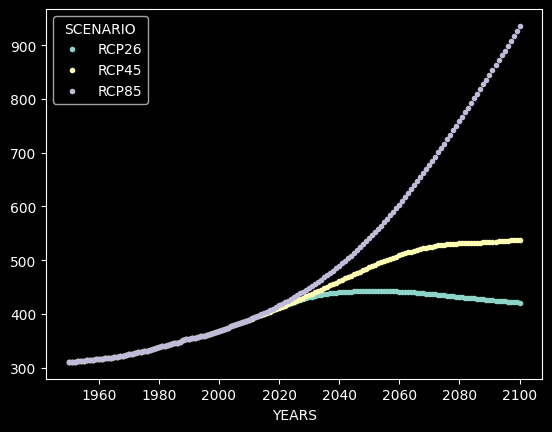

In [11]:
co2_scenarios.plot(style=".")